Updated Accuracy: 0.5793


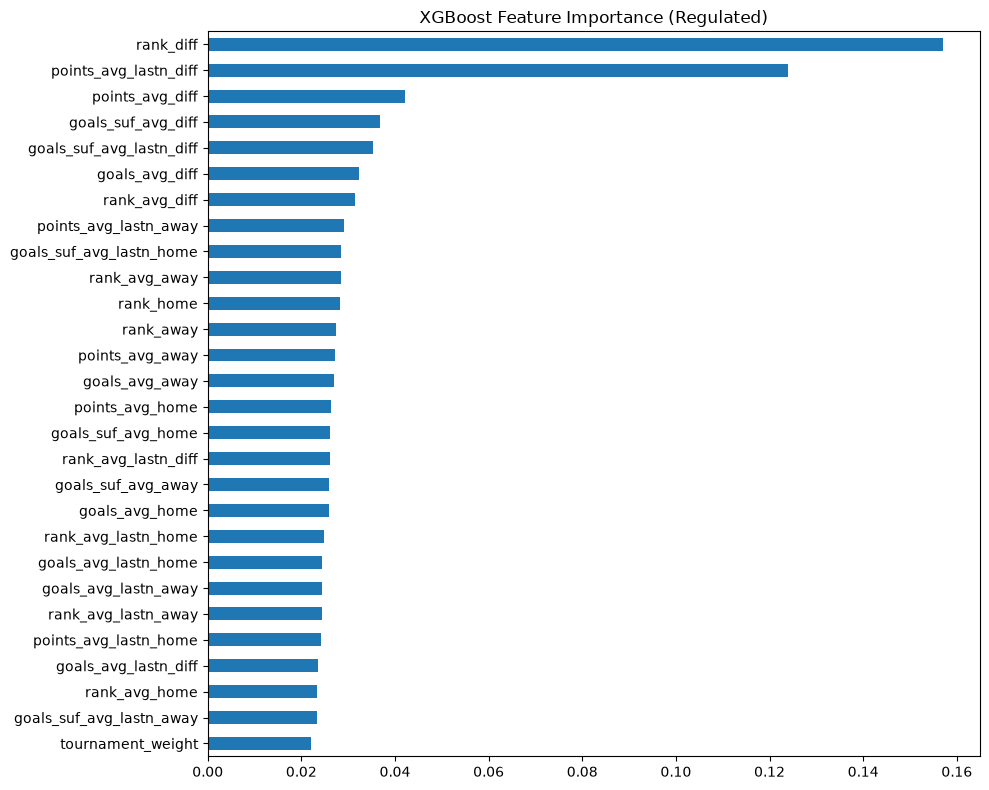

In [ ]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

df = pd.read_csv('final_updated.csv')

# 타겟 생성
def get_result(row):
    if row['home_score'] > row['away_score']: return 2
    elif row['home_score'] == row['away_score']: return 1
    else: return 0

df['result'] = df.apply(get_result, axis=1)

# 피처 선택 (스코어 관련 컬럼 제외)
drop_cols = ['date', 'home_team', 'away_team', 'home_score', 'away_score',
             'goals_scored_home', 'goals_scored_away', 'result']
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols].fillna(0)
y = df['result']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05,
                      eval_metric='mlogloss', random_state=42)
model.fit(X_train, y_train)

print(f"Accuracy: {accuracy_score(y_test, model.predict(X_test)):.4f}")

# Feature Importance 시각화
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=True)
importances.plot(kind='barh', figsize=(10, 8), title='XGBoost Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

In [6]:
# points_avg_lastn_diff (중요도 ~0.23)
# 컬럼 의미: 홈팀과 어웨이팀의 최근 N경기 평균 승점 차이

In [7]:
#rank_diff (중요도 ~0.11)
#컬럼 의미: 홈팀과 어웨이팀의 FIFA 랭킹 차이